# 05 · CUB70 and CBM — does a positive concept require visible pixels?

Professor Ramaswamy's question is evaluated on real CUB photographs with CUB70 part masks.

For concept `j`, the original processed CUB label is `c_j`. The model produces raw value `z_j` and probability `c_pred_j`. The mask gives `visible_part(j)`.

We restrict the main test to rows with `c_j=1`, then compare:

`c_pred_j | visible_part(j)=1` versus `c_pred_j | visible_part(j)=0`.

If an originally-positive concept falls when its named part is not visible, the output is responsive to visible evidence. If it remains high, information elsewhere in the image is sufficient to produce that concept.

This is an observational occlusion test, not a deletion counterfactual: naturally visible and occluded images may differ in pose, species, and background. It can demonstrate a grounding problem but cannot by itself identify species as the unique source.


## Direct comparison with the FunnyBird CBM evidence chain

The aim is to test whether the *pattern* found causally in FunnyBirds also appears in
real CUB photographs. The measurements are kept as parallel as the datasets allow.

| FunnyBird CBM question | CUB test | Directly comparable? | CUB limitation |
|---|---|---|---|
| Does a present concept score high on ordinary images? | positive-label concept output | yes, descriptively | CUB labels may already be species-majority targets |
| Does removing the named part lower its concept? | mask-visible versus naturally mask-absent photographs | same question, weaker test | different photographs also differ in pose, background, and species |
| Does more visible part evidence strengthen the output? | within-part mask-area dose response | approximately | pixel area is not the same as diagnostic visual information |
| Does donor beat source after a fixed swap? | unavailable | no | CUB has no paired renderer intervention |
| Does the effect remain after species is fixed? | within-(species, concept) visible-minus-occluded comparison | yes, observationally | pose and viewpoint remain uncontrolled |
| Do visibility-aware training labels repair grounding? | unavailable with current masks | no | CUB70 masks cover evaluation images, not the training set |

**Pre-result prediction.** If CUB has the same nonlocal-grounding problem, positive
outputs should often remain high with the named mask absent, visibility dose response
should be weak for at least some parts, and a smaller effect may remain after species
and concept are fixed. If the FunnyBird result were only a synthetic-renderer artifact,
CUB outputs should instead track natural mask visibility strongly.

**Conclusion rule.** CUB can corroborate the same observational pattern. It cannot by
itself prove that species caused an individual prediction; the paired FunnyBird
swap/deletion experiment remains the causal source test.


In [1]:
import os, sys
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt

CURATED = Path(os.environ["CURATED_DATA"])
CWD = Path.cwd(); REPO = CWD if (CWD/"analysis").is_dir() else CWD.parent
sys.path.insert(0, str(REPO/"analysis"))
sys.path.insert(0, str(REPO/"data"/"cub70"))
from occlusion import (attach_visibility, z_by_visibility, grounding_violation_rate,
    quartile_grounding, within_species_visibility_effect,
    visibility_specificity_control)
from relabel_cub_with_cub70 import coarse_visibility
try:
    from plotting import set_paper_style, PALETTE; set_paper_style(); CBM_C=PALETTE["CBM"]
except Exception: CBM_C="#0072B2"

def need(p, how):
    p=Path(p)
    if not p.exists(): print(f"[pending] {p}\n  produce it: {how}")
    return p.exists()

vis_path=CURATED/"cub70_visibility.parquet"
VIS=None
if need(vis_path, "bash data/cub70/prepare_all.sh"):
    VIS=coarse_visibility(pd.read_parquet(vis_path), threshold=0.001).rename(columns={"coarse":"part"})
    print(f"masks: {VIS.image_name.nunique()} images, parts={sorted(VIS.part.unique())}")


masks: 1888 images, parts=['beak', 'body', 'eye', 'head', 'leg', 'neck', 'tail', 'wing']


## 1 · Full-CUB-trained CBM on the masked CUB70 images

First use the CBM trained on all 200 CUB classes. Joining its test predictions to CUB70 masks automatically restricts the analysis to masked images.

For every part, print:

- `prob_mean = mean(c_pred_j | c_j=1, visible)`;
- `z_median = median(z_j | c_j=1, visible)`;
- `violation_rate = P(c_pred_j≥0.5 | c_j=1, visible=0)`.

Here “violation” means the model still reports an originally-positive concept when its named part mask is absent. Because the image was not actively edited, it is evidence of nonlocal sufficiency, not proof that species alone caused the answer.


,part,visible,n,z_mean,z_median,prob_mean
0,beak,False,304,0.114,0.309,0.659
1,beak,True,3777,0.538,0.599,0.703
2,body,False,363,-0.618,-0.444,0.717
3,body,True,15248,-0.584,-0.543,0.759
4,eye,False,884,-0.380,-0.280,0.499
5,eye,True,836,-0.272,-0.212,0.499
6,head,False,44,-0.595,-0.620,0.724
7,head,True,5074,-0.937,-0.684,0.764
8,leg,False,333,0.109,0.059,0.594
9,leg,True,979,-0.391,-0.259,0.636


,part,n_occluded,violation_rate
0,beak,304,0.711
1,body,363,0.782
2,eye,884,0.001
3,head,44,0.932
4,leg,333,0.661
5,neck,877,0.863
6,tail,230,0.822
7,wing,924,0.817


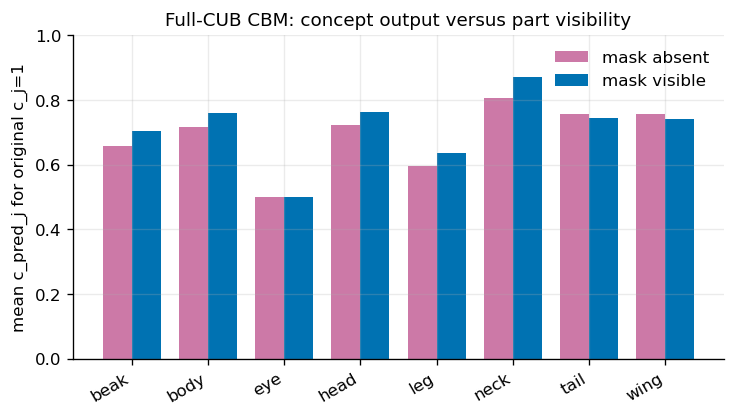

In [2]:
SEED=1
full_path=CURATED/"cub70_eval"/f"cub-cbm-s{SEED}.parquet"
J_FULL=None
if VIS is not None and need(full_path, "CONFIGS='cub-cbm' SEEDS='1' bash analysis/cub70_prepare_analysis.sh"):
    E=pd.read_parquet(full_path)
    J_FULL=attach_visibility(E[E.part!=""], VIS)
    Z=z_by_visibility(J_FULL); display(Z.round(3))
    V=grounding_violation_rate(J_FULL); display(V.round(3))
    P=Z.pivot(index="part",columns="visible",values="prob_mean").rename(columns={False:"occluded",True:"visible"})
    fig,ax=plt.subplots(figsize=(7,3.5)); x=np.arange(len(P)); w=.38
    ax.bar(x-w/2,P.get("occluded"),w,label="mask absent",color="#CC79A7")
    ax.bar(x+w/2,P.get("visible"),w,label="mask visible",color=CBM_C)
    ax.set_xticks(x); ax.set_xticklabels(P.index,rotation=30,ha="right")
    ax.set_ylim(0,1); ax.set_ylabel("mean c_pred_j for original c_j=1")
    ax.set_title("Full-CUB CBM: concept output versus part visibility"); ax.legend(); plt.show()


## 2 · Does the amount of visible area matter?

A binary mask-present flag may hide a graded relationship. Among rows with `c_j=1`, divide `area_frac` into within-part quartiles and compute

`mean(c_pred_j | visibility quartile)`.

A rising curve means the concept output tracks how much of the part is visible. A flat high curve means the same answer is produced with little or much visible part evidence. Counts are required because some part/visibility groups may be small.


,part,qbin,n,prob_mean,z_mean,area_frac_mean
0,beak,1,1021,0.6983,0.3095,0.0012
1,beak,2,1020,0.7004,0.5629,0.0024
2,beak,3,1020,0.7124,0.7336,0.0038
3,beak,4,1020,0.6893,0.4193,0.0088
4,body,1,3903,0.7390,-0.4816,0.0111
5,body,2,3903,0.7596,-0.5540,0.0265
6,body,3,3902,0.7759,-0.5964,0.0450
7,body,4,3903,0.7579,-0.7059,0.0933
8,eye,1,430,0.4994,-0.3719,0.0003
9,eye,2,430,0.4994,-0.3887,0.0008


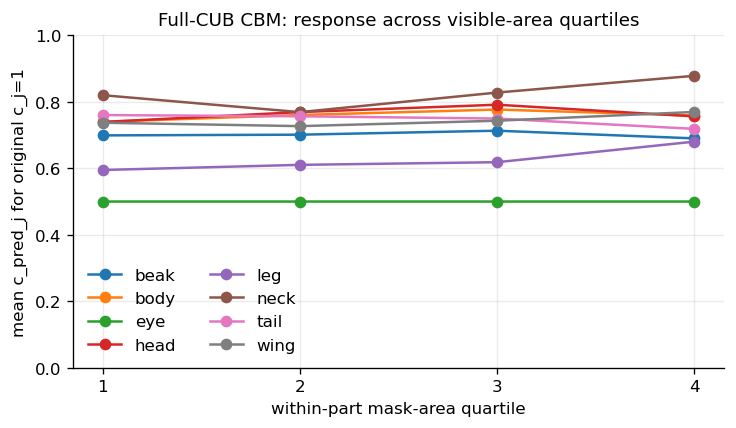

In [3]:
if J_FULL is not None:
    Q=quartile_grounding(J_FULL); display(Q.round(4))
    fig,ax=plt.subplots(figsize=(7,3.6))
    for part,d in Q.groupby("part"):
        ax.plot(d.qbin,d.prob_mean,"o-",label=part)
    ax.set_xticks(sorted(Q.qbin.unique())); ax.set_xlabel("within-part mask-area quartile")
    ax.set_ylabel("mean c_pred_j for original c_j=1"); ax.set_ylim(0,1)
    ax.set_title("Full-CUB CBM: response across visible-area quartiles"); ax.legend(ncol=2); plt.show()


## 3 · What does visibility relabeling change?

CUB70 masks exist only for test images. We may therefore ask how many evaluation labels change from `c_j=1` to visible-absence `c_j^vis=0`, but we cannot claim to have retrained the model with these masks.

For mapped attribute `j`:

`c_j^vis = c_j × visible_part(j)`.

The flip table measures label/mask disagreement by part. It answers whether segmentation adds information beyond the species-level label. It is not an original-versus-relabeled training comparison.


,considered,flipped,flip_rate_all,original_positive,flip_rate_given_positive
part,,,,,
beak,16992,304,0.018,4081,0.074
body,79296,363,0.005,15611,0.023
eye,1888,884,0.468,1720,0.514
head,37760,44,0.001,5118,0.009
leg,5664,333,0.059,1312,0.254
neck,9440,877,0.093,1192,0.736
tail,7552,230,0.030,1697,0.136
wing,33984,924,0.027,6101,0.151


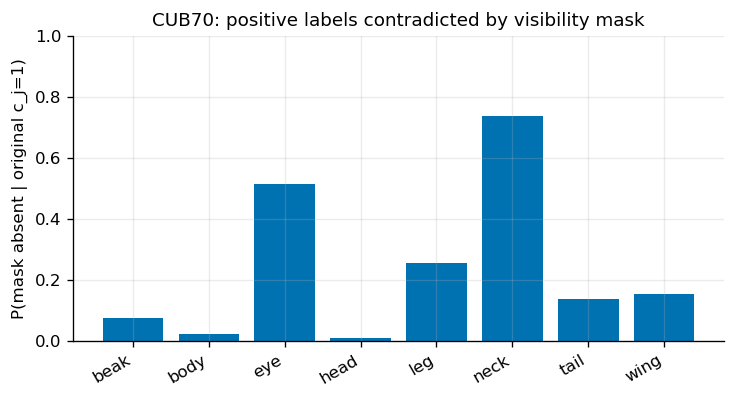

In [4]:
diag_path=CURATED/"cub70_relabel_diagnostics.parquet"
if need(diag_path, "python data/cub70/relabel_cub_with_cub70.py"):
    D=pd.read_parquet(diag_path)
    S=(D.groupby("part").agg(considered=("flipped","size"),flipped=("flipped","sum")))
    S["flip_rate_all"]=S.flipped/S.considered
    pos=D[D.original_label==1].groupby("part").agg(original_positive=("flipped","size"),flipped=("flipped","sum"))
    pos["flip_rate_given_positive"]=pos.flipped/pos.original_positive
    R=S.join(pos[["original_positive","flip_rate_given_positive"]]); display(R.round(3))
    fig,ax=plt.subplots(figsize=(7,3.3)); ax.bar(R.index,R.flip_rate_given_positive,color=CBM_C)
    ax.set_ylim(0,1); ax.set_ylabel("P(mask absent | original c_j=1)")
    ax.set_title("CUB70: positive labels contradicted by visibility mask"); plt.xticks(rotation=30,ha="right"); plt.show()


## 4 · Repeat after training a genuine 70-class CBM

The full-CUB and CUB70-trained models are evaluated on the same masked images with the same original labels. The only intended model-side change is that the second model was trained to distinguish 70 rather than 200 species.

Compare `violation_rate` and the visible/occluded probability gap. This addresses the professor's “same test for the CUB70 model” request. It does not constitute visibility-aware retraining because training masks do not exist.


,model,part,n_occluded,violation_rate
0,full-CUB trained,beak,304,0.711
1,full-CUB trained,body,363,0.782
2,full-CUB trained,eye,884,0.001
3,full-CUB trained,head,44,0.932
4,full-CUB trained,leg,333,0.661
5,full-CUB trained,neck,877,0.863
6,full-CUB trained,tail,230,0.822
7,full-CUB trained,wing,924,0.817
8,CUB70 trained,beak,304,0.615
9,CUB70 trained,body,363,0.590


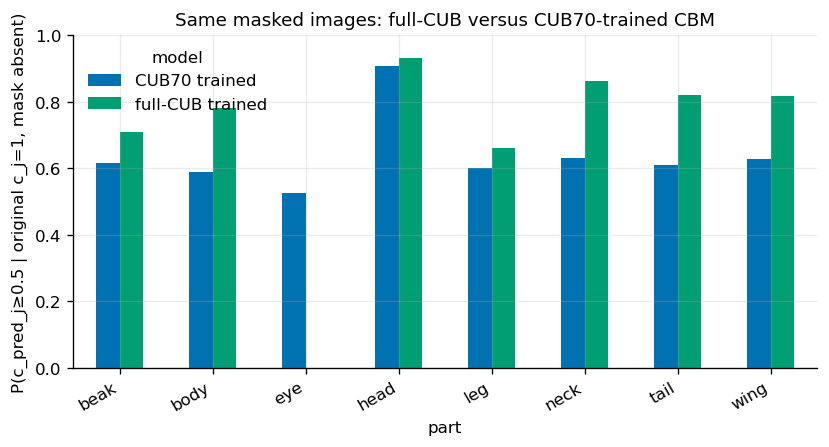

In [5]:
cub70_path=CURATED/"cub70_eval"/f"cub70-cbm-s{SEED}.parquet"
if VIS is not None and need(cub70_path, "SEEDS='1' bash train/cbm_cub70.sh; then CONFIGS='cub70-cbm' bash analysis/cub70_prepare_analysis.sh"):
    E70=pd.read_parquet(cub70_path); J70=attach_visibility(E70[E70.part!=""],VIS)
    rows=[]
    for name,J in [("full-CUB trained",J_FULL),("CUB70 trained",J70)]:
        if J is None: continue
        v=grounding_violation_rate(J)
        rows += [dict(model=name,part=r.part,n_occluded=r.n_occluded,violation_rate=r.violation_rate) for r in v.itertuples()]
    C=pd.DataFrame(rows); display(C.round(3))
    H=C.pivot(index="part",columns="model",values="violation_rate")
    H.plot.bar(figsize=(8,3.6),ylim=(0,1),color=[CBM_C,"#009E73"])
    plt.ylabel("P(c_pred_j≥0.5 | original c_j=1, mask absent)")
    plt.title("Same masked images: full-CUB versus CUB70-trained CBM"); plt.xticks(rotation=30,ha="right"); plt.show()


## 5 · Odd result: is the eye output grounded or collapsed?

The full-CUB eye violation bar is almost zero, but the preceding tables place its
mean probability near 0.5 for both visible and hidden eyes. A near-zero thresholded
violation is not evidence of good grounding if the predictor simply emits one
constant value below 0.5.

**Discriminating test.** For each model and part, measure probability standard
deviation, range, and number of distinct rounded values among originally-positive
rows. Then inspect the complete eye distribution split by mask visibility.

- broad, separated eye distributions would support genuine visibility response;
- a narrow spike at one value would identify output collapse or a mapping problem.


In [ ]:
collapse_rows=[]; task_rows=[]
model_frames=[]
if J_FULL is not None:
    model_frames.append(("full-CUB trained",J_FULL))
if "J70" in globals() and J70 is not None:
    model_frames.append(("CUB70 trained",J70))
for model,J in model_frames:
    images=J[["image","y_true","y_pred"]].drop_duplicates("image")
    task_rows.append({
        "model":model,"n_images":len(images),
        "task_accuracy":(images.y_true==images.y_pred).mean(),
    })
    for part,d in J[J.gt_label==1].groupby("part"):
        collapse_rows.append({
            "model":model,"part":part,"n":len(d),
            "prob_mean":d.prob.mean(),"prob_std":d.prob.std(),
            "prob_min":d.prob.min(),"prob_max":d.prob.max(),
            "unique_prob_6dp":d.prob.round(6).nunique(),
        })
MODEL_TASK=pd.DataFrame(task_rows)
COLLAPSE=pd.DataFrame(collapse_rows)
display(MODEL_TASK.round(4))
display(COLLAPSE.sort_values(["part","model"]).round(6))

if model_frames:
    fig,axes=plt.subplots(1,len(model_frames),figsize=(6*len(model_frames),3.7),
                          squeeze=False,sharex=True,sharey=True)
    bins=np.linspace(0,1,51)
    for ax,(model,J) in zip(axes[0],model_frames):
        eye=J[(J.part=="eye")&(J.gt_label==1)]
        for visible,color in [(False,"#CC79A7"),(True,CBM_C)]:
            d=eye[eye.visible==visible]
            ax.hist(d.prob,bins=bins,alpha=.55,color=color,
                    label=f"visible={visible}, n={len(d)}")
        ax.axvline(.5,color="black",ls="--",lw=.8)
        ax.set_title(model);ax.set_xlabel("eye concept probability")
        ax.legend(fontsize=8)
    axes[0,0].set_ylabel("rows")
    fig.suptitle("Eye output distribution: grounding response or collapsed score?")
    fig.tight_layout();plt.show()


**Conclusion boundary.** A collapsed eye output must be reported as model failure or
calibration/mapping failure, not as successful grounding. The CUB70-trained eye
result is interpreted separately because changing the number of species may alter
whether the eye concept is learned at all.


## 5 · Species-matched control

<!-- SPECIES-MATCHED CONTROL -->
The previous plots can accidentally compare one set of species when a part is visible with a different set when it is hidden. That matters because standard CUB concept labels are species-majority labels.

For each fixed triple `(species y, concept j, part)` that contains both visible and occluded photographs, calculate

`Δ_yj = mean(c_pred_j | visible, y, j) − mean(c_pred_j | occluded, y, j)`.

Then average `Δ_yj` within each part. Positive `Δ_yj` means visibility still matters after holding species and the exact concept fixed. Near-zero `Δ_yj` means the naive gap was largely between species. This removes the species main effect, but pose and viewpoint remain observational confounds.


,part,n_matched_groups,n_visible,n_occluded,visible_mean,occluded_mean,visible_minus_occluded
0,beak,105,2730.0,304.0,0.7107,0.6506,0.0600
1,body,188,4942.0,363.0,0.7740,0.6731,0.1009
2,eye,59,836.0,854.0,0.4994,0.4994,-0.0000
3,head,21,567.0,44.0,0.7727,0.7718,0.0009
4,leg,42,829.0,333.0,0.6225,0.6023,0.0202
5,neck,31,263.0,588.0,0.8268,0.7972,0.0296
6,tail,55,1317.0,230.0,0.7488,0.7254,0.0234
7,wing,156,3481.0,924.0,0.7413,0.6765,0.0648


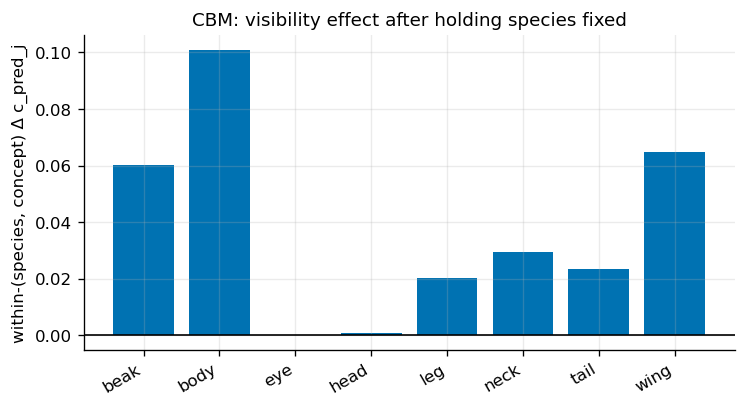

In [7]:
if J_FULL is not None:
    MATCHED=within_species_visibility_effect(J_FULL)
    display(MATCHED.round(4))
    fig,ax=plt.subplots(figsize=(7,3.4))
    ax.bar(MATCHED.part,MATCHED.visible_minus_occluded,color=CBM_C)
    ax.axhline(0,color="black",lw=1)
    ax.set_ylabel("within-(species, concept) Δ c_pred_j")
    ax.set_title("CBM: visibility effect after holding species fixed")
    plt.xticks(rotation=30,ha="right");plt.show()


## 6 · Negative-label specificity control

The grounding claim concerns concepts with `c_j=1`. We also calculate the visible-minus-occluded probability difference when `c_j=0`. If positive and negative labels move together, visibility may be acting as a general pose or image-quality signal instead of evidence specific to the named positive concept.


,part,gt_label,n_visible,n_occluded,prob_visible,prob_occluded,visible_minus_occluded
0,beak,0,12018,893,0.2055,0.2211,-0.0156
1,beak,1,3777,304,0.7034,0.6589,0.0446
2,body,0,62326,1359,0.1612,0.1791,-0.0179
3,body,1,15248,363,0.7591,0.7174,0.0417
4,eye,0,45,123,0.4994,0.4994,0.0000
5,eye,1,836,884,0.4994,0.4994,-0.0000
6,head,0,32426,216,0.1499,0.1840,-0.0341
7,head,1,5074,44,0.7635,0.7237,0.0399
8,leg,0,3302,1050,0.2523,0.3381,-0.0858
9,leg,1,979,333,0.6359,0.5942,0.0416


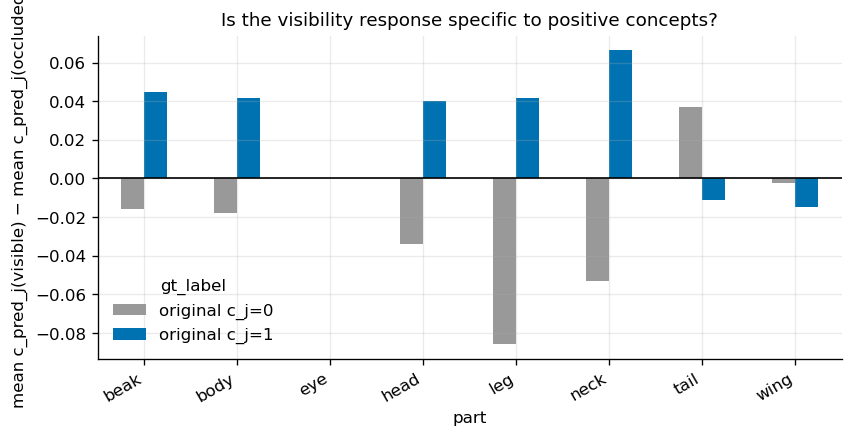

In [8]:
if J_FULL is not None:
    CONTROL=visibility_specificity_control(J_FULL)
    display(CONTROL.round(4))
    H=CONTROL.pivot(index="part",columns="gt_label",values="visible_minus_occluded")
    H=H.rename(columns={0:"original c_j=0",1:"original c_j=1"})
    H.plot.bar(figsize=(8,3.5),color=["#999999",CBM_C])
    plt.axhline(0,color="black",lw=1)
    plt.ylabel("mean c_pred_j(visible) − mean c_pred_j(occluded)")
    plt.title("Is the visibility response specific to positive concepts?")
    plt.xticks(rotation=30,ha="right");plt.show()


## 8 · Odd result: why do tail and wing reverse after species matching?

In the pooled positive-label comparison, tail and wing can score slightly *lower*
when visible. In the within-species control, both become slightly positive. This is
a possible species-composition reversal: naturally visible and hidden photographs
contain different mixtures of species.

**Discriminating test.** Put the pooled and species-matched estimates side by side,
then show every eligible `(species, concept)` visibility effect. If the matched
distribution is centered above zero while the pooled estimate is negative, species
composition explains the sign reversal. Wide positive and negative matched effects
would instead show genuine species-specific heterogeneity.


In [ ]:
if J_FULL is not None:
    pooled=(CONTROL[CONTROL.gt_label==1]
            .set_index("part").visible_minus_occluded.rename("pooled"))
    matched=(MATCHED.set_index("part").visible_minus_occluded
             .rename("species_matched"))
    REVERSAL=pd.concat([pooled,matched],axis=1).reset_index()
    REVERSAL["sign_reversal"]=(
        np.sign(REVERSAL.pooled)!=np.sign(REVERSAL.species_matched)
    )
    display(REVERSAL.round(4))

    pos=J_FULL[J_FULL.gt_label==1]
    effects=(pos.groupby(["part","y_true","concept_idx","visible"]).prob.mean()
             .unstack("visible").dropna())
    effects["effect"]=effects[True]-effects[False]
    effects=effects.reset_index()
    EFFECT_SUMMARY=(effects.groupby("part").effect.agg(
        n_groups="size",mean="mean",median="median",
        q25=lambda x:x.quantile(.25),q75=lambda x:x.quantile(.75),
        fraction_positive=lambda x:(x>0).mean(),
    ).reset_index())
    display(EFFECT_SUMMARY.round(4))
    fig,ax=plt.subplots(figsize=(8,4))
    rng=np.random.default_rng(20260731)
    for i,part in enumerate(sorted(effects.part.unique())):
        values=effects.loc[effects.part==part,"effect"].to_numpy()
        ax.scatter(i+rng.uniform(-.16,.16,len(values)),values,
                   s=13,alpha=.35,color=CBM_C)
    ordered=sorted(effects.part.unique())
    med=effects.groupby("part").effect.median().reindex(ordered)
    ax.scatter(range(len(ordered)),med,s=65,marker="_",color="black",
               linewidth=2,label="matched-group median")
    ax.axhline(0,color="black",lw=.8)
    ax.set_xticks(range(len(ordered)));ax.set_xticklabels(ordered,rotation=30,ha="right")
    ax.set_ylabel("visible − occluded probability within (species, concept)")
    ax.set_title("Species-matched visibility effects: distribution behind the mean")
    ax.legend(fontsize=8);plt.show()


**Limited conclusion rule.** Species matching can diagnose composition bias, but it
remains observational. A causal source-species claim still requires changing body
or species context while holding the target part fixed—an intervention available in
FunnyBirds but not in these natural CUB photographs.


## 9 · Seed support and final decision

A single seed is exploratory. Load every exported `cub-cbm-s*.parquet`, repeat the species-matched effect, and print the number of seeds. The notebook may describe a pattern from one seed, but it may call it dependable only when the same sign appears across independent seeds.


In [10]:
seed_rows=[]
if VIS is not None:
    for path in sorted((CURATED/"cub70_eval").glob("cub-cbm-s*.parquet")):
        seed=int(path.stem.rsplit("-s",1)[1])
        J=attach_visibility(pd.read_parquet(path).query("part != ''"),VIS)
        for r in within_species_visibility_effect(J).itertuples():
            seed_rows.append(dict(seed=seed,part=r.part,n_matched_groups=r.n_matched_groups,
                                  visible_minus_occluded=r.visible_minus_occluded))
if seed_rows:
    SEEDS=pd.DataFrame(seed_rows);display(SEEDS.round(4))
    SUMMARY=(SEEDS.groupby("part").visible_minus_occluded
             .agg(["mean","std","count","min","max"]).reset_index())
    display(SUMMARY.round(4))
    print("Plain reading: positive means the named part's visibility still changes c_pred_j "
          "after species and concept are held fixed. count is the number of model seeds.")
else:
    print("[pending] export at least one full-CUB CBM: CONFIGS='cub-cbm' SEEDS='1' bash analysis/cub70_prepare_analysis.sh")


,seed,part,n_matched_groups,visible_minus_occluded
0,1,beak,105,0.0600
1,1,body,188,0.1009
2,1,eye,59,-0.0000
3,1,head,21,0.0009
4,1,leg,42,0.0202
5,1,neck,31,0.0296
6,1,tail,55,0.0234
7,1,wing,156,0.0648


,part,mean,std,count,min,max
0,beak,0.0600,NaN,1,0.0600,0.0600
1,body,0.1009,NaN,1,0.1009,0.1009
2,eye,-0.0000,NaN,1,-0.0000,-0.0000
3,head,0.0009,NaN,1,0.0009,0.0009
4,leg,0.0202,NaN,1,0.0202,0.0202
5,neck,0.0296,NaN,1,0.0296,0.0296
6,tail,0.0234,NaN,1,0.0234,0.0234
7,wing,0.0648,NaN,1,0.0648,0.0648


Plain reading: positive means the named part's visibility still changes c_pred_j after species and concept are held fixed. count is the number of model seeds.


## Integrated conclusion boundary

Notebook 05 repeats the FunnyBird CBM grounding questions wherever CUB permits:
ordinary positive outputs, natural part absence, visibility dose response,
species matching, negative-label specificity, collapse checks, and seed support.

A matching CUB pattern strengthens external validity: the concept can remain high
without visible named-part evidence in real photographs, not only synthetic birds.
But CUB cannot turn that observation into the same causal statement because its
visible and hidden cases are different photographs. It also cannot reproduce RLv2
training with the current test-only masks. The causal claims therefore remain
anchored by fixed FunnyBird deletion/swap interventions; CUB asks whether the same
warning signs generalize to a natural dataset.
